# Introdução à Inteligência Artificial e Fundamentos de Python

## O Algoritmo *k*-means - Continuação: o método do cotovelo (*elbow method*)

O algorítmo básico do K-Means é baseado nas seguintes etapas:
* escolha de *k*, o número de grupos ou *clusters*
* determinação dos centróides
* associação dos pontos ao centróide mais próximo
* otimização iterativa de forma que os pontos de cada grupo fiquem próximos de seu centróide. 

<div>
<img src="k means-Cgpt.png" width="400" height="700">   
</div>



    Fonte: Inteligência Artificial

O problema que surge em algumas situações,e: como escolher *k*, o número ideal de grupos? Se escolhemos *k*=1, todos os pontos ficam em um único grupo, por outro lado para *k*=10 pode-se obtter uma representação melhor dos dados. No método do cotovelo o número de grupos é incrementado iterattivamente até o ponto em que os ganhos na representação começam a ficar muito reduzidos (cotovelo). 

Para fazer a avaliação dos ganhos com o aumento do valor de *k* são utilizadas com frequência uma das duas métricas seguintes: inércia (ou WCSS - Within Cluster Sum of Squares) e distorção. A inércia é a soma dos quadrados das distâncias dos pontos aos respectivos centróides. A distorção, nessa definição, é simplesmente a inércia dividida pelo número de pontos, ou s média dos erros medidos pela inércia.
  

Importação de bibliotecas

In [8]:
from sklearn.cluster import KMeans 
from scipy.spatial.distance import cdist 
import numpy as np 
import matplotlib.pyplot as plt

Criação dos dados

In [27]:
x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6,
               7, 8, 9, 8, 9, 9, 8, 4, 4, 5, 4])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7,
               1, 2, 1, 2, 3, 2, 3, 9, 10, 9, 10])

# Transforma a lista de pontos em uma matriz NumPy
X = np.array(list(zip(x1, x2)))
print(X.shape)
print("\n", X[:5,:])


(21, 2)

 [[3 5]
 [1 4]
 [1 5]
 [2 6]
 [1 5]]


Visualização dos pontos (dados)

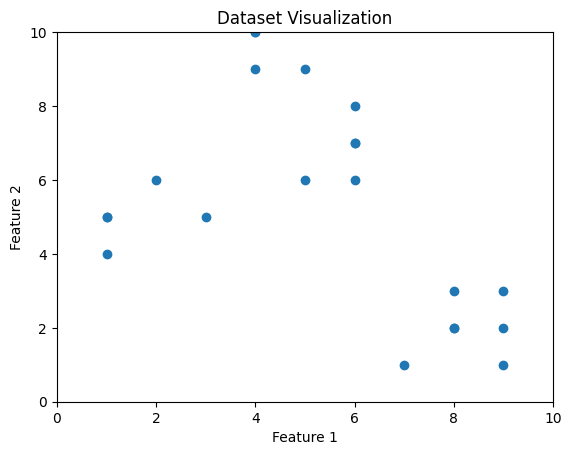

In [17]:
plt.scatter(x1, x2, marker='o') 
plt.xlim([0, 10]) 
plt.ylim([0, 10]) 
plt.title('Dataset Visualization') 
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2')
plt.show()



*Elbow Method*

In [21]:
distortions=[]
inertias=[]
K=range(1,10)
for k in K:
    #-------------------------
    # Cria e ajusta o K-means
    #------------------------
    model=KMeans(n_clusters=k,random_state=42)
    model.fit(X)

    #-------------------------
    # Cálculo dos centróides
    #------------------------
    centroids=model.cluster_centers_

    #-------------------------------------------------------
    # Calcula a distância de cada ponto para cada centróide
    #--------------------------------------------------------
    dist = cdist( X, centroids, 'euclidean' )

    #---------------------------------------------------------------
    # para cada ponto, retorna a menor distância e eleva ao quadrado
    #---------------------------------------------------------------
    min_dist= np.min( dist, axis=1 )
    square_dist=(min_dist**2)

    #---------------------------------------------------------------
    # Soma os quadrados, calcula a distorção e armazena os resultados
    #----------------------------------------------------------------
    sumation_sq_dist = np.sum( square_dist)
    distortion=(sumation_sq_dist/X.shape[0])
    distortions.append(distortion)
    inertias.append(model.inertia_)

Impressão dos valores de distorção e inércia

In [24]:
print("Distortions")
for k,value in zip(K,distortions):
    print(k,":",value)
print("\nInertia values")
for k,value in zip(K,inertias):
    print(k,":",value)
    

Distortions
1 : 14.90249433106576
2 : 5.14625850340136
3 : 1.8817838246409675
4 : 0.8561224489795918
5 : 0.7166666666666667
6 : 0.5484126984126984
7 : 0.43253968253968256
8 : 0.3817460317460318
9 : 0.3341269841269841

Inertia values
1 : 312.95238095238096
2 : 108.07142857142856
3 : 39.51746031746032
4 : 17.978571428571428
5 : 15.049999999999999
6 : 11.516666666666666
7 : 9.083333333333332
8 : 8.016666666666667
9 : 7.0166666666666675


Gráfico da distorção

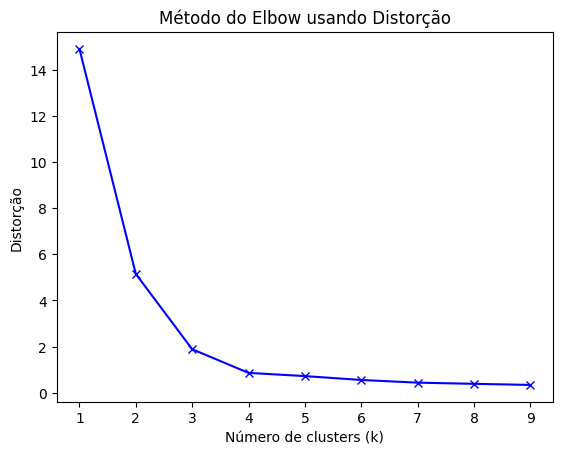

In [25]:
plt.plot( K, distortions, 'bx-' )
plt.xlabel('Número de clusters (k)')
plt.ylabel('Distorção') 
plt.title('Método do Elbow usando Distorção')
plt.show()

Gráfico da inércia

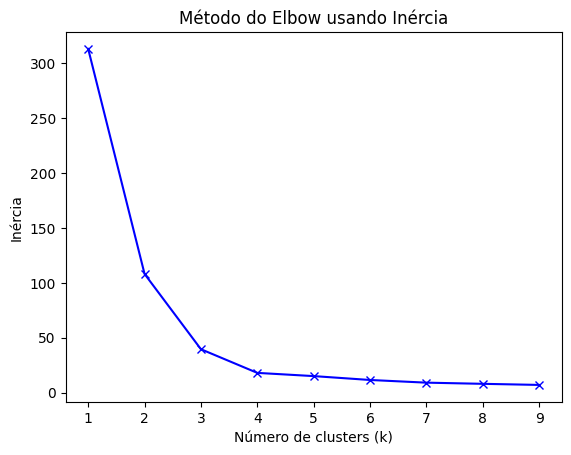

In [26]:
plt.plot( K, inertias, 'bx-' ) 
plt.xlabel('Número de clusters (k)') 
plt.ylabel('Inércia') 
plt.title('Método do Elbow usando Inércia')
plt.show()

$$\boxed{
\text{pontos}
\rightarrow
\text{distâncias}
\rightarrow
\text{menor distância}
\rightarrow
\text{quadrado}
\rightarrow
\text{soma}
\rightarrow
\text{inércia}
}$$

$$
\boxed{
\text{inércia}
\rightarrow
\frac{\text{inércia}}{n}
\rightarrow
\text{distorção}
}
$$